# Exploratory_Data_Analysis of Pakistan Stock Exchange (PSX)

This notebook performs time series analysis and data quality validation on the cleaned PSX historical dataset before portfolio optimization.

## Objectives

- Load the cleaned PSX master dataset
- Validate time-series quality
- Check missing values
- Detect duplicate records
- Verify missing trading dates
- Calculate daily returns
- Detect outliers
- Analyze rolling volatility
- Visualize historical price trends
- Export validated dataset

- Import Libraries

In [33]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import plotly.express as px

- Load Dataset

In [34]:
df = pd.read_csv("../data/processed/PSX_2015_2025_Master_Data.csv")

df.head()

,Date,Symbol,Open,High,Low,Close,Adj Close,Volume
0,2015-01-01,ABL,113.250000,113.900002,112.510002,113.550003,33.938301,283800
1,2015-01-02,ABL,113.000000,115.000000,113.000000,114.029999,34.081764,508800
2,2015-01-05,ABL,114.150002,114.500000,113.599998,114.010002,34.075790,384200
3,2015-01-06,ABL,113.800003,114.750000,113.500000,113.669998,33.974163,458500
4,2015-01-07,ABL,113.550003,114.290001,113.099998,113.599998,33.953247,240400


- Dataset Information

In [35]:
df.shape

df.info()

df.describe()

df.columns

<class 'pandas.DataFrame'>
RangeIndex: 269825 entries, 0 to 269824
Data columns (total 8 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   Date       269825 non-null  str    
 1   Symbol     269825 non-null  str    
 2   Open       269825 non-null  float64
 3   High       269825 non-null  float64
 4   Low        269825 non-null  float64
 5   Close      269825 non-null  float64
 6   Adj Close  269825 non-null  float64
 7   Volume     269825 non-null  int64  
dtypes: float64(5), int64(1), str(2)
memory usage: 20.1 MB


Index(['Date', 'Symbol', 'Open', 'High', 'Low', 'Close', 'Adj Close',
       'Volume'],
      dtype='str')

- Convert Date

In [36]:
df["Date"] = pd.to_datetime(df["Date"])

df = df.sort_values(["Symbol","Date"])

- Missing Values

In [37]:
df.isnull().sum()

Date         0
Symbol       0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

- Duplicate Records

In [38]:
duplicates = df.duplicated()

duplicates.sum()

np.int64(0)

- Duplicate Symbol + Date

In [39]:
duplicate_dates = df.duplicated(
    subset=["Symbol","Date"]
)

duplicate_dates.sum()

np.int64(0)

- Number of Trading Days

In [40]:
df.groupby("Symbol")["Date"].count()

Symbol
ABL      2851
ABOT     2851
ACPL     2851
AGHA     1328
AGP      1974
         ... 
THCCL    2851
TRG      2851
UBL      2852
UNITY    2851
UPFL     2854
Name: Date, Length: 99, dtype: int64

- Daily Returns

In [41]:
df["Daily_Return"] = (
    df.groupby("Symbol")["Adj Close"]
      .pct_change()
)

- Daily Return Summary

In [42]:
df["Daily_Return"].describe()

count    269726.000000
mean          0.000889
std           0.030796
min          -0.890436
25%          -0.010025
50%           0.000000
75%           0.009592
max           4.013950
Name: Daily_Return, dtype: float64

- Outlier Detection (IQR)

In [43]:
Q1 = df["Daily_Return"].quantile(0.25)

Q3 = df["Daily_Return"].quantile(0.75)

IQR = Q3 - Q1

outliers = df[
    (df["Daily_Return"] < Q1-1.5*IQR) |
    (df["Daily_Return"] > Q3+1.5*IQR)
]

outliers

,Date,Symbol,Open,High,Low,Close,Adj Close,Volume,Daily_Return
63,2015-03-31,ABL,90.000000,94.610001,90.000000,94.610001,28.852707,112100,0.049939
65,2015-04-02,ABL,98.489998,102.900002,98.489998,101.970001,31.097250,277300,0.040510
144,2015-07-22,ABL,101.900002,106.059998,100.000000,106.000000,32.832527,1008900,0.049401
167,2015-08-24,ABL,96.000000,96.250000,94.779999,94.930000,29.899616,83900,-0.048320
168,2015-08-25,ABL,94.500000,99.650002,94.500000,99.650002,31.386242,219100,0.049721
...,...,...,...,...,...,...,...,...,...
269711,2025-07-23,UPFL,28999.000000,30554.939453,26500.000000,30554.939453,29061.148438,162,0.100000
269712,2025-07-24,UPFL,31000.000000,33610.429688,31000.000000,33610.429688,31967.261719,163,0.100000
269735,2025-08-27,UPFL,31169.000000,32500.000000,30526.000000,32320.000000,30739.914062,429,0.065345
269758,2025-09-29,UPFL,32001.000000,32205.000000,30000.000000,30500.310547,29392.283203,471,-0.055952


- Largest Daily Returns

In [44]:
df.nlargest(10, "Daily_Return")

,Date,Symbol,Open,High,Low,Close,Adj Close,Volume,Daily_Return
258289,2025-07-03,THCCL,186.000000,189.899994,183.000000,186.899994,186.899994,1344141,4.013950
149299,2025-08-14,KOHC,467.510010,467.510010,467.510010,467.510010,467.510010,0,4.000000
124701,2025-06-04,ICI,1562.510010,1575.000000,1550.000000,1558.660034,1501.627197,3272,3.987680
160591,2025-03-03,LUCK,1415.250000,1434.000000,1409.000000,1412.719971,1400.886230,161766,3.959836
249679,2025-04-14,SYS,515.000000,516.000000,502.000000,503.559998,495.733154,174619,3.955616
155019,2025-09-04,KTML,254.899994,256.000000,249.000000,250.100006,242.689636,9601,3.912977
263982,2025-06-19,UBL,520.000000,522.900024,516.020020,521.400024,480.082855,381538,1.021283
263977,2025-06-12,UBL,516.000000,526.989990,516.000000,520.200012,478.977936,965451,1.017178
263945,2025-04-29,UBL,475.600006,483.989990,468.500000,475.130005,437.479401,2716568,0.978554
251347,2020-09-09,TELE,1.275747,2.002214,1.275747,1.949058,1.949058,22061418,0.447368


- Lowest Daily Returns

In [45]:
df.nsmallest(10, "Daily_Return")

,Date,Symbol,Open,High,Low,Close,Adj Close,Volume,Daily_Return
163317,2024-09-05,MARI,405.666656,411.111115,395.555542,398.968903,367.216919,1563741,-0.890436
249676,2025-04-09,SYS,99.800003,101.000000,94.699997,97.346001,95.832954,2671455,-0.806234
258287,2025-07-01,THCCL,38.400002,38.439999,37.400002,37.570000,37.570000,1518755,-0.802419
258291,2025-07-07,THCCL,37.599998,38.000000,37.000000,37.070000,37.070000,3320785,-0.801552
124725,2025-07-10,ICI,357.799988,362.000000,353.028015,356.660004,343.609467,98580,-0.800643
124699,2025-06-02,ICI,307.600006,309.000000,306.000000,306.287994,295.080627,13450,-0.800524
160588,2025-02-26,LUCK,291.600006,295.196014,290.000000,291.985992,289.540131,1248690,-0.799499
155021,2025-09-08,KTML,51.000000,52.400002,50.000000,51.580002,50.051704,134510,-0.798618
149297,2025-08-12,KOHC,92.000000,92.865997,91.699997,92.206001,92.206001,546160,-0.798593
160617,2025-04-10,LUCK,320.600006,325.200012,316.002014,320.365997,317.682434,3984900,-0.794766


In [46]:
len(outliers)

28589

- Rolling Volatility

In [47]:
df["Rolling_Volatility"] = (
    df.groupby("Symbol")["Daily_Return"]
      .rolling(30)
      .std()
      .reset_index(level=0,drop=True)
)

- Price Trend

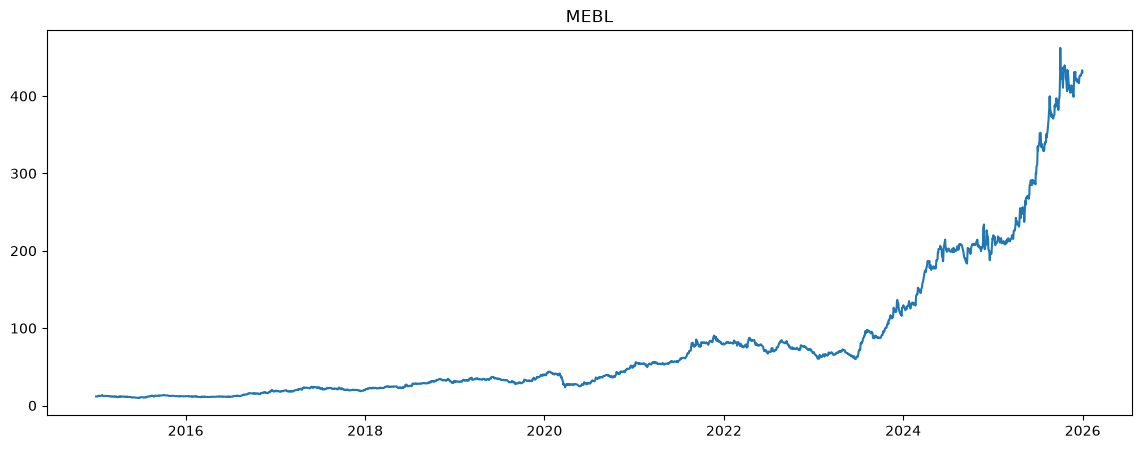

In [48]:
stock = "MEBL"

temp = df[df["Symbol"]==stock]

plt.figure(figsize=(14,5))

plt.plot(
    temp["Date"],
    temp["Adj Close"]
)

plt.title(stock)

plt.show()

- Daily Return Trend

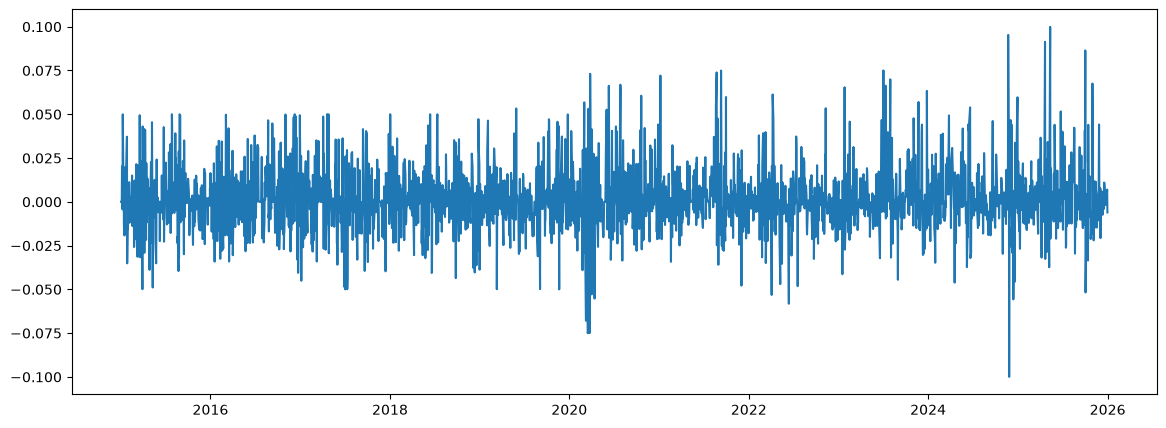

In [49]:
plt.figure(figsize=(14,5))

plt.plot(
    temp["Date"],
    temp["Daily_Return"]
)

plt.show()

- Rolling Volatility Trend

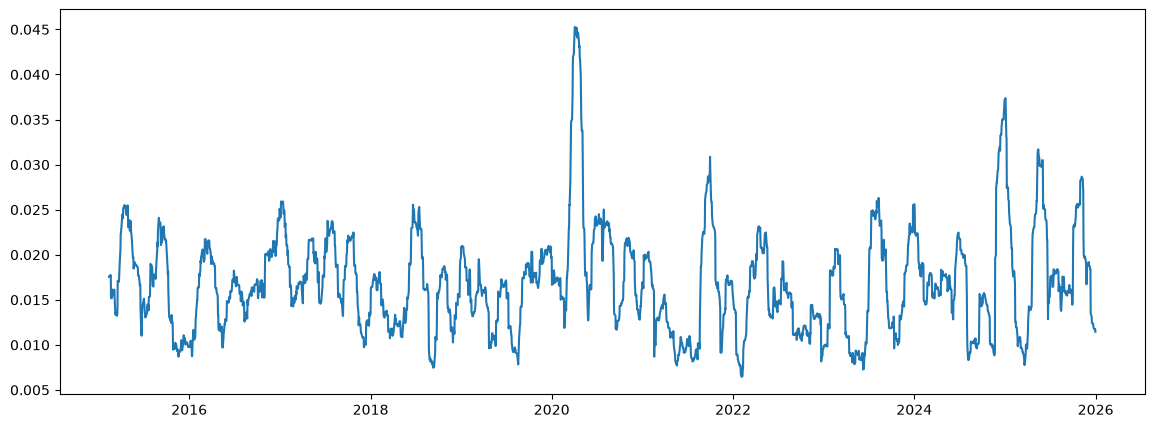

In [50]:
plt.figure(figsize=(14,5))

plt.plot(
    temp["Date"],
    temp["Rolling_Volatility"]
)

plt.show()

- Final Validation

In [51]:
print(df.shape)

print(df.isnull().sum())

print(df.duplicated().sum())

(269825, 10)
Date                     0
Symbol                   0
Open                     0
High                     0
Low                      0
Close                    0
Adj Close                0
Volume                   0
Daily_Return            99
Rolling_Volatility    2970
dtype: int64
0


-Box Plot

C:\Users\MOHSIN\AppData\Local\Temp\ipykernel_21620\4205065783.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


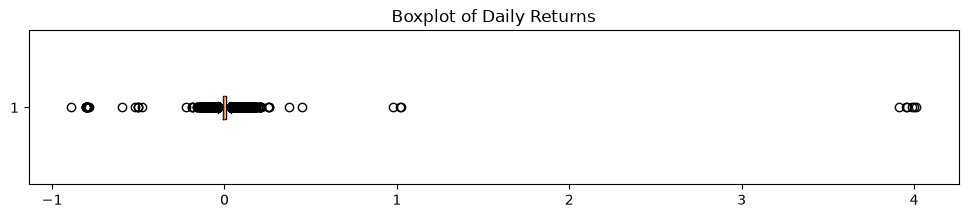

In [52]:
plt.figure(figsize=(12,2))

plt.boxplot(
    df["Daily_Return"].dropna(),
    vert=False
)

plt.title("Boxplot of Daily Returns")

plt.show()

In [53]:
# Flag suspicious price movements above +50% or below -50%
suspicious = df[
    (df["Daily_Return"] > 0.50) |
    (df["Daily_Return"] < -0.50)
].copy()

print("Total suspicious records:", len(suspicious))
print("Companies affected:", suspicious["Symbol"].nunique())

suspicious[
    ["Date", "Symbol", "Adj Close", "Daily_Return"]
].sort_values("Daily_Return", ascending=False)

Total suspicious records: 25
Companies affected: 8


,Date,Symbol,Adj Close,Daily_Return
258289,2025-07-03,THCCL,186.899994,4.013950
149299,2025-08-14,KOHC,467.510010,4.000000
124701,2025-06-04,ICI,1501.627197,3.987680
160591,2025-03-03,LUCK,1400.886230,3.959836
249679,2025-04-14,SYS,495.733154,3.955616
155019,2025-09-04,KTML,242.689636,3.912977
263982,2025-06-19,UBL,480.082855,1.021283
263977,2025-06-12,UBL,478.977936,1.017178
263945,2025-04-29,UBL,437.479401,0.978554
263975,2025-06-10,UBL,236.197235,-0.500205


In [54]:
import pandas as pd

df = pd.read_csv(
    "../data/processed/psx_2015_2025_Master_Data.csv",
    parse_dates=["Date"]
)

# Date order
df = df.sort_values(["Symbol", "Date"])

# Daily returns
df["ret"] = df.groupby("Symbol")["Close"].pct_change()

# Suspicious movements — investigation ke liye
suspects = df[df["ret"].abs() > 0.5]

print(suspects[
    ["Date", "Symbol", "Close", "ret"]
])

             Date Symbol        Close       ret
124699 2025-06-02    ICI   306.287994 -0.800524
124701 2025-06-04    ICI  1558.660034  3.987680
124725 2025-07-10    ICI   356.660004 -0.800643
149297 2025-08-12   KOHC    92.206001 -0.798593
149299 2025-08-14   KOHC   467.510010  4.000000
149301 2025-08-18   KOHC    98.678001 -0.788811
155017 2025-09-02   KTML    51.779999 -0.792706
155019 2025-09-04   KTML   250.100006  3.912977
155021 2025-09-08   KTML    51.580002 -0.798618
160588 2025-02-26   LUCK   291.985992 -0.799499
160591 2025-03-03   LUCK  1412.719971  3.959836
160617 2025-04-10   LUCK   320.365997 -0.794766
163317 2024-09-05   MARI   398.968903 -0.890436
249676 2025-04-09    SYS    97.346001 -0.806234
249679 2025-04-14    SYS   503.559998  3.955616
249703 2025-05-19    SYS   269.950012 -0.503577
249709 2025-05-27    SYS   108.820000 -0.595134
258287 2025-07-01  THCCL    37.570000 -0.802419
258289 2025-07-03  THCCL   186.899994  4.013950
258291 2025-07-07  THCCL    37.070000 -0

-Histogram (Distribution)

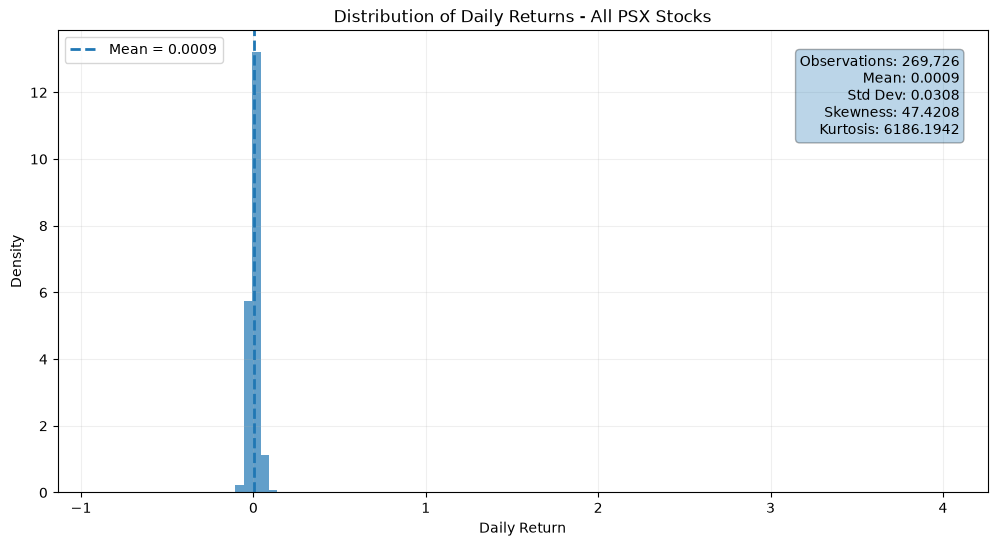

In [55]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis

# ------------------------------------------------------------
# 1. PREPARE DATA
# ------------------------------------------------------------

# Convert Date to datetime
df["Date"] = pd.to_datetime(df["Date"])

# Sort each stock chronologically
df = df.sort_values(["Symbol", "Date"]).copy()

# ------------------------------------------------------------
# 2. CALCULATE DAILY RETURNS FOR ALL STOCKS AND ALL DATES
# ------------------------------------------------------------

df["Daily_Return"] = (
    df.groupby("Symbol")["Adj Close"]
      .pct_change(fill_method=None)
)

# Remove NaN returns only for analysis
returns = df["Daily_Return"].dropna()


# ------------------------------------------------------------
# 3. CALCULATE DISTRIBUTION STATISTICS
# ------------------------------------------------------------

mean_return = returns.mean()
std_return = returns.std()
skewness = skew(returns)
kurt = kurtosis(returns)


# ------------------------------------------------------------
# 4. PLOT DISTRIBUTION OF ALL DAILY RETURNS
# ------------------------------------------------------------

plt.figure(figsize=(12, 6))

plt.hist(
    returns,
    bins=100,
    density=True,
    alpha=0.7
)

# Mean line
plt.axvline(
    mean_return,
    linestyle="--",
    linewidth=2,
    label=f"Mean = {mean_return:.4f}"
)

# Statistics box
stats_text = (
    f"Observations: {len(returns):,}\n"
    f"Mean: {mean_return:.4f}\n"
    f"Std Dev: {std_return:.4f}\n"
    f"Skewness: {skewness:.4f}\n"
    f"Kurtosis: {kurt:.4f}"
)

plt.text(
    0.97,
    0.95,
    stats_text,
    transform=plt.gca().transAxes,
    verticalalignment="top",
    horizontalalignment="right",
    bbox=dict(boxstyle="round", alpha=0.3)
)

plt.title("Distribution of Daily Returns - All PSX Stocks")
plt.xlabel("Daily Return")
plt.ylabel("Density")

plt.legend()
plt.grid(alpha=0.2)

plt.show()

## Final Analysis Summary

The historical Pakistan Stock Exchange (PSX) dataset was examined to evaluate data quality, daily stock returns, outliers, and volatility patterns before portfolio optimization.

### Key Findings

- The dataset contains approximately 269,825 observations covering 99 PSX-listed stocks.
- No missing values were found in the original historical price columns.
- No duplicate records or duplicate Symbol-Date combinations were identified.
- The number of available trading observations varies across stocks, indicating that some companies have shorter historical data coverage than others.
- Daily returns were calculated separately for each stock using Adjusted Close prices.
- The average daily return across the dataset is approximately 0.000889, while most daily returns are concentrated close to zero.
- Significant extreme returns were detected in the dataset. The maximum observed daily return is approximately 4.01395 (401%), while the minimum is approximately -0.89044 (-89%).
- IQR-based outlier detection identified 28,589 observations as statistical outliers. However, an IQR outlier does not necessarily represent incorrect market data, so these observations should not be automatically removed.
- The box plot and extreme-return analysis revealed several unusually large positive and negative returns, particularly values approaching +400% and -90%. These observations require further validation because they may result from corporate actions, price adjustments, data inconsistencies, or genuine market movements.
- The daily return trend shows that returns generally fluctuate around zero, with periods of larger price movements.
- Rolling volatility analysis indicates that market risk changes over time and exhibits periods of volatility clustering. Several significant volatility spikes are visible, particularly around 2020 and during more recent periods.
- The first daily return for each stock is naturally `NaN` because no previous trading observation exists for calculating percentage change. Rolling volatility also contains initial `NaN` values because a minimum number of observations is required to calculate the rolling window.

### Outlier Treatment

The original historical price data will remain unchanged. Statistical outliers identified through the IQR method will be used primarily for exploratory analysis rather than being automatically deleted.

Extreme daily returns that are confirmed to result from data errors, incorrect price adjustments, or other data-quality issues will be replaced with `NaN` in the return series used for subsequent risk and portfolio calculations. Genuine extreme market movements will be retained.

This approach preserves the integrity of the original dataset while reducing the risk that erroneous observations could distort volatility estimates and portfolio optimization results.

### Conclusion

Overall, the dataset is structurally clean, with no missing values in the original price data and no duplicate observations. However, the return analysis reveals several extreme observations that require validation before the final portfolio optimization stage.

The analysis also demonstrates that PSX stock returns are concentrated around relatively small daily movements but experience occasional extreme fluctuations and changing levels of volatility over time. After validating suspicious extreme returns, the resulting return series can be used for stock-level risk analysis and portfolio optimization.